<a href="https://colab.research.google.com/github/KrisDA-1/ML.Fraud_Detection/blob/main/ML_FinalAssessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK1. Data analysis and opportunity identification



##>>>Data analysis and opportunity identification


###Terms about dataset
V1 - V28 = PCA (Principal component analysis)- transformed features derived from the original transaction attributes.

Time = Seconds since the first transaction

Amount = Actual transaction amount

Class= Fraud (1) or legitimate (0)

In [2]:
##Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
##Read the excel file and display the first rows of the DataFrame
df=pd.read_excel('creditcard.xlsx')
print(df.head()) ##Using print is important so we ensure the original dataset is used without problem


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
##Checking the shape of the df
df.shape

(284807, 31)

In [5]:
##Checking the data types and missing values
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
##Checking columns in the data
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
##Checking the count of unique categories in all object type columns
unique_counts = df.select_dtypes(include='object').nunique()

print(unique_counts)

Series([], dtype: float64)


###>>>Missing Values

In [8]:
##Percentage of missing values per column
print(df.isnull().mean()*100)

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64


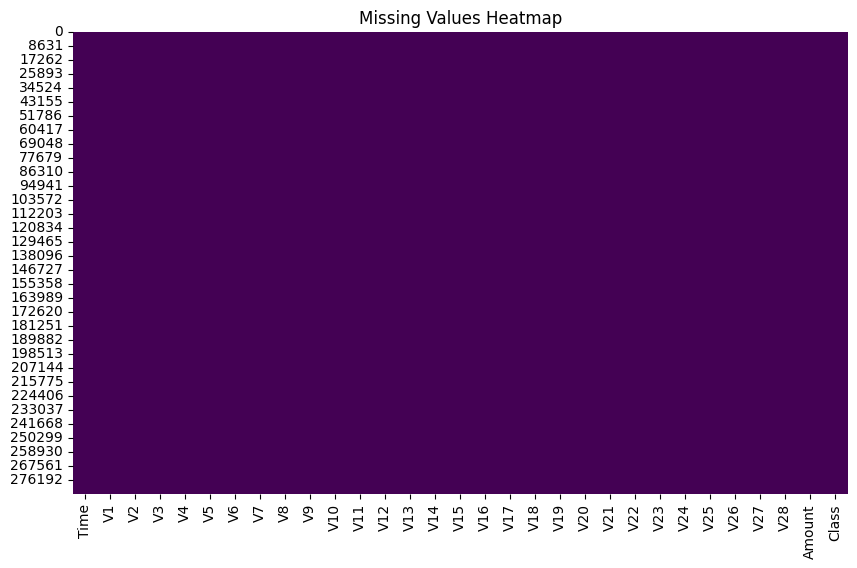

In [9]:
##Visualise Missingness using a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

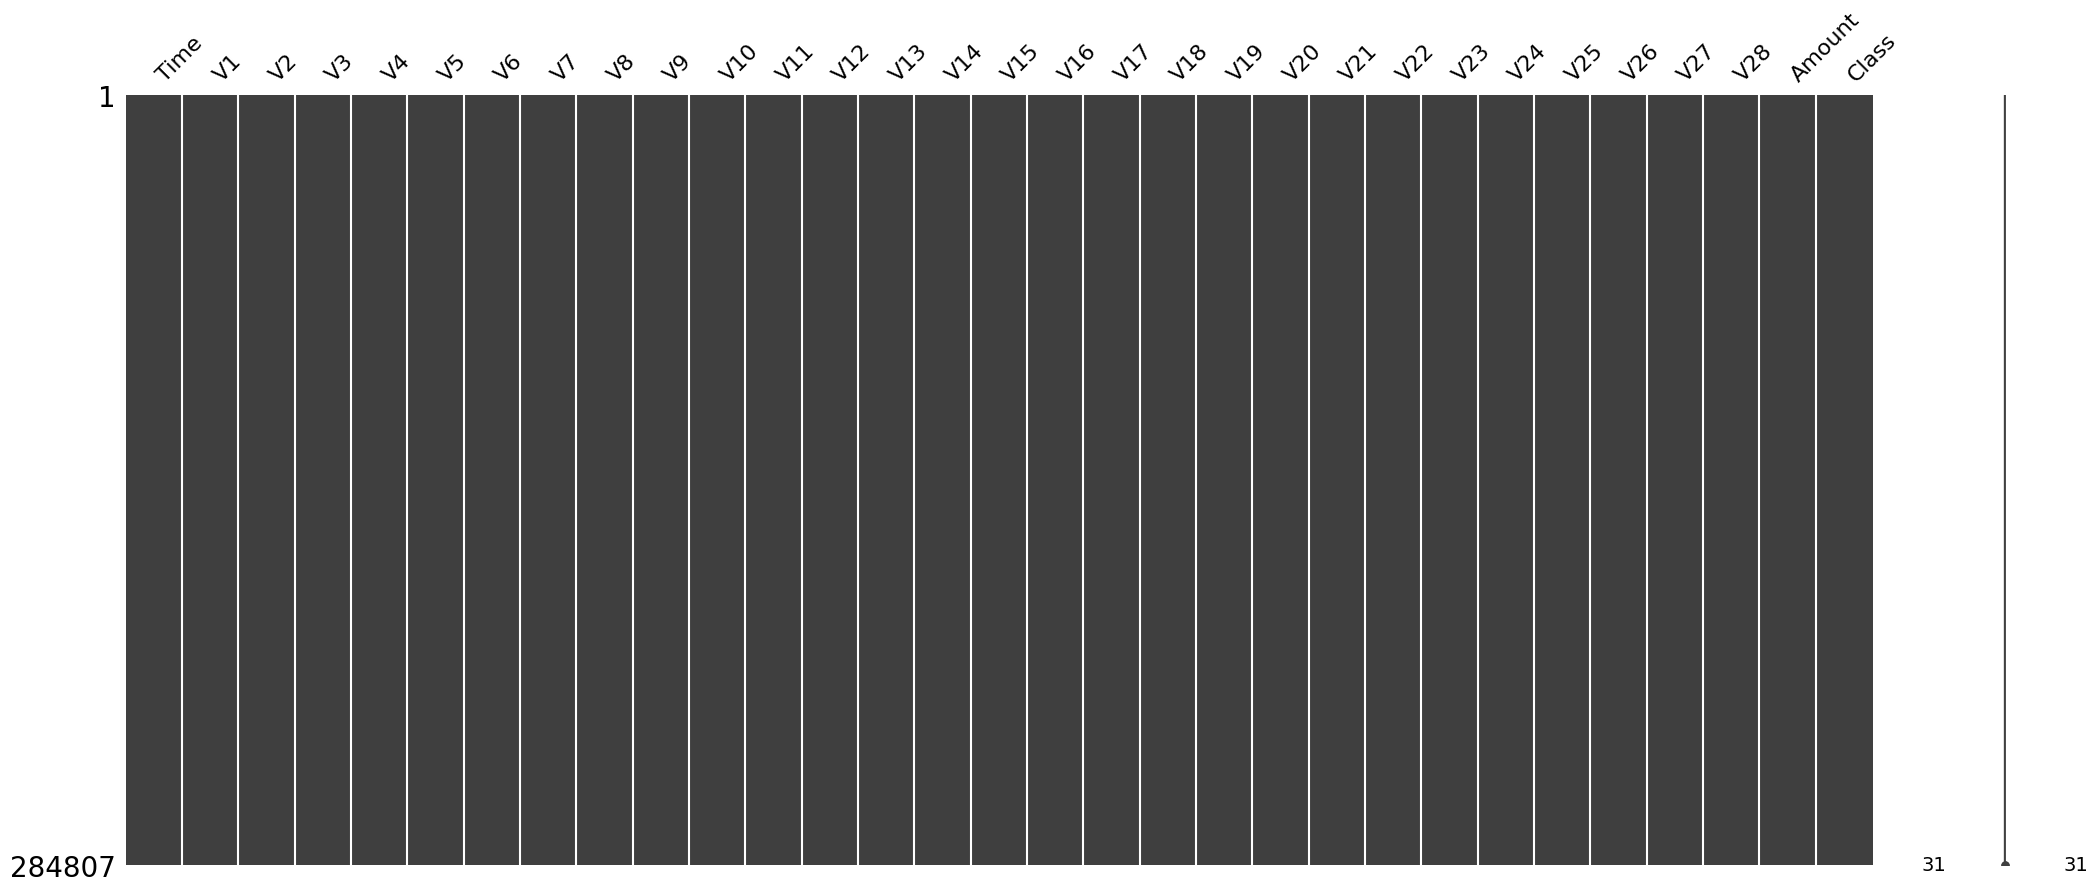

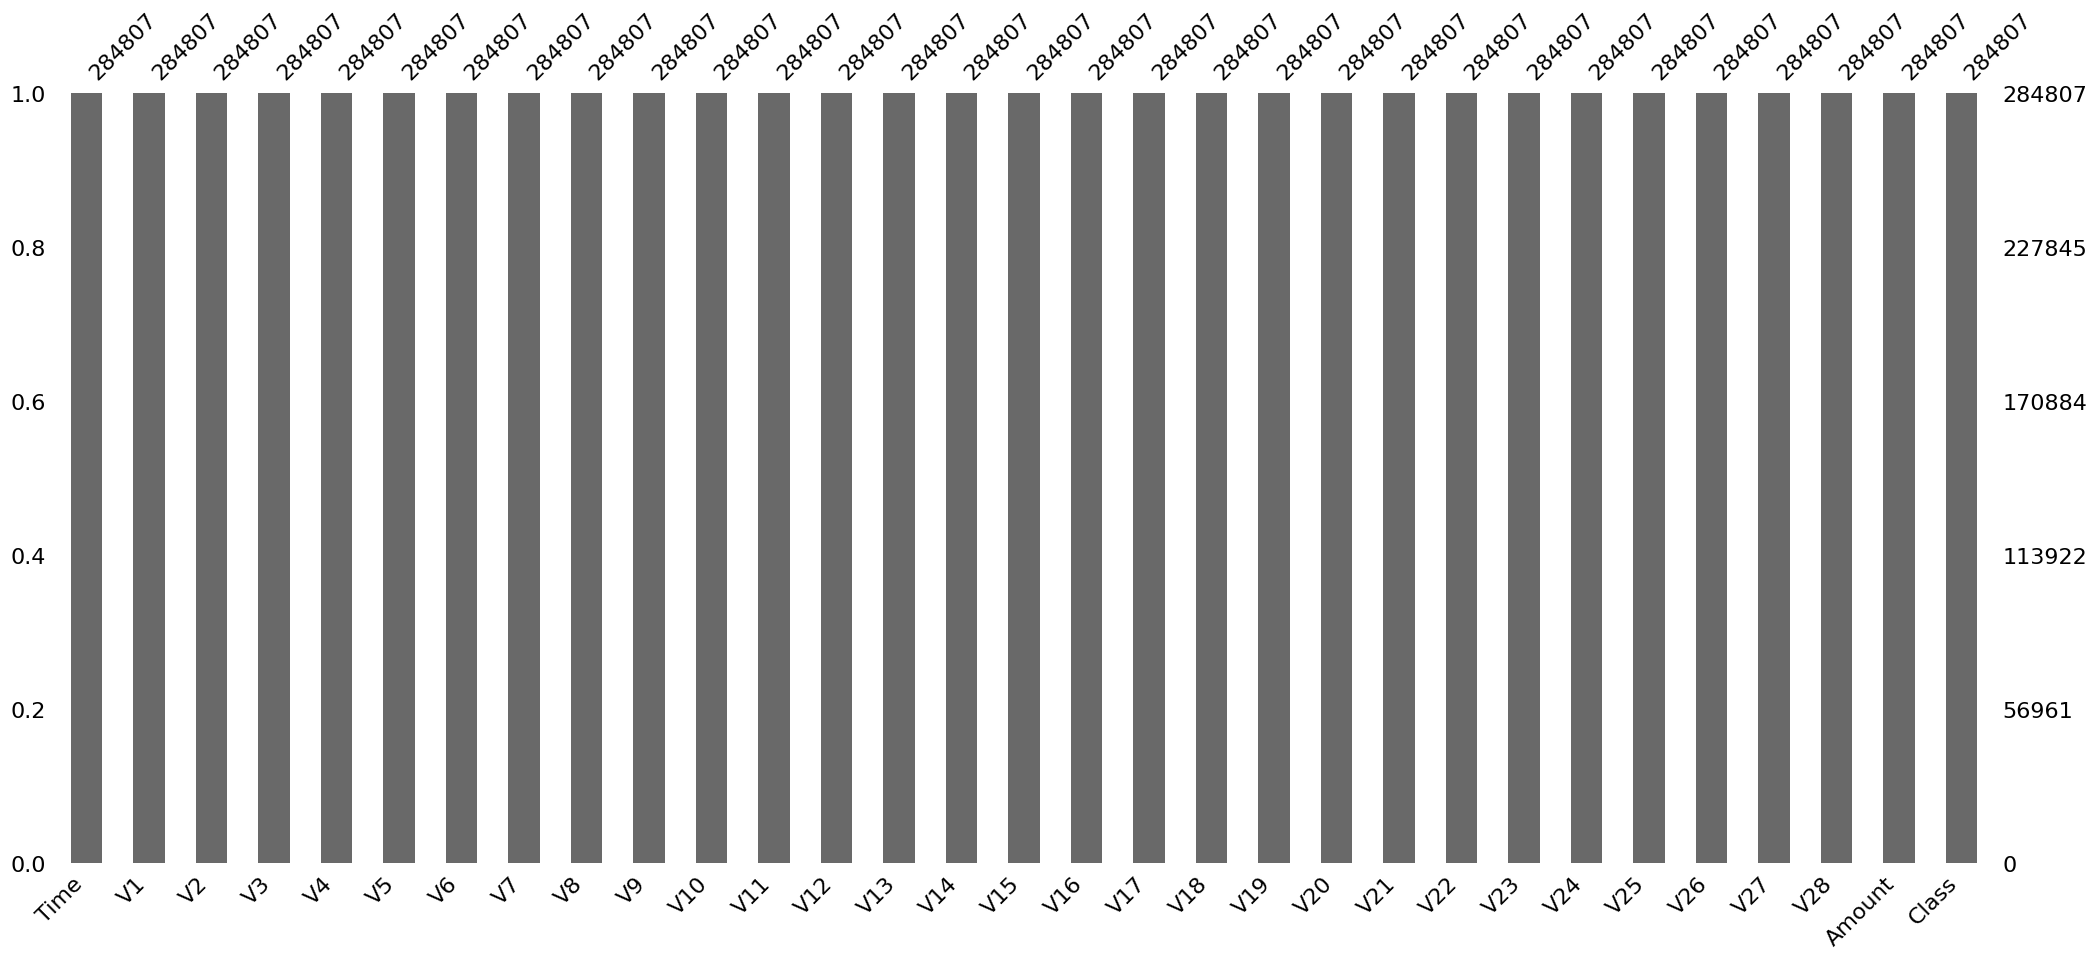

In [10]:
##Visual Toolkit for Missing
#### Highlitghts which rows have missing data

!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt

###Shows completeness of each row - Matrix plot
#### shows missing count/percentage per column
msno.matrix(df)
plt.show()

###Missing couunt per column - Bar plot
#### Shows relationships, if column A missing often implies B missing
msno.bar(df)
plt.show()



In [11]:
##See only rows containing missing values
missing_rows=df[df.isnull().any(axis=1)]
print(missing_rows)

Empty DataFrame
Columns: [Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Class]
Index: []

[0 rows x 31 columns]


In [12]:
##Other way to see missing values (no missing values)
total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
##Statistical summary for numeric and non-numeric columns
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.205498e-16,-2.406306e-15,...,1.656562e-16,-3.568593e-16,2.610582e-16,4.473066e-15,5.213180e-16,1.683537e-15,-3.659966e-16,-1.223710e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
#Checking null values
df.isnull().sum().max()

0

###>>>Basic Class Distribution (Fraud vs No fraud)

In [15]:
#Evaluating how imbalance is our original dataset
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


/tmp/ipython-input-3646104730.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

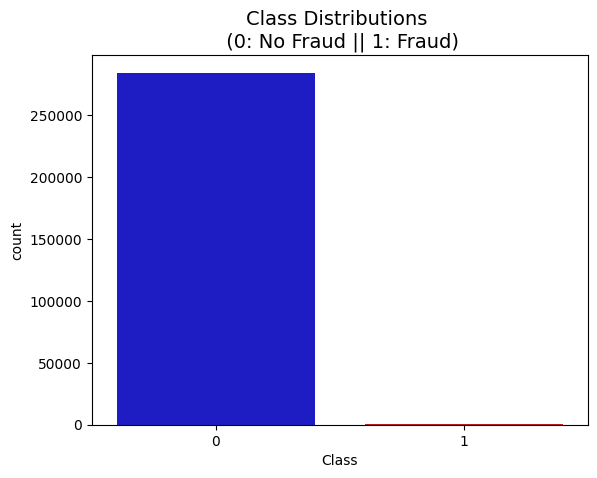

In [16]:
##Our dataset is so imbalanced!, which can lead us to errors if we use it as that in our model. We are going to solve this issue later.
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

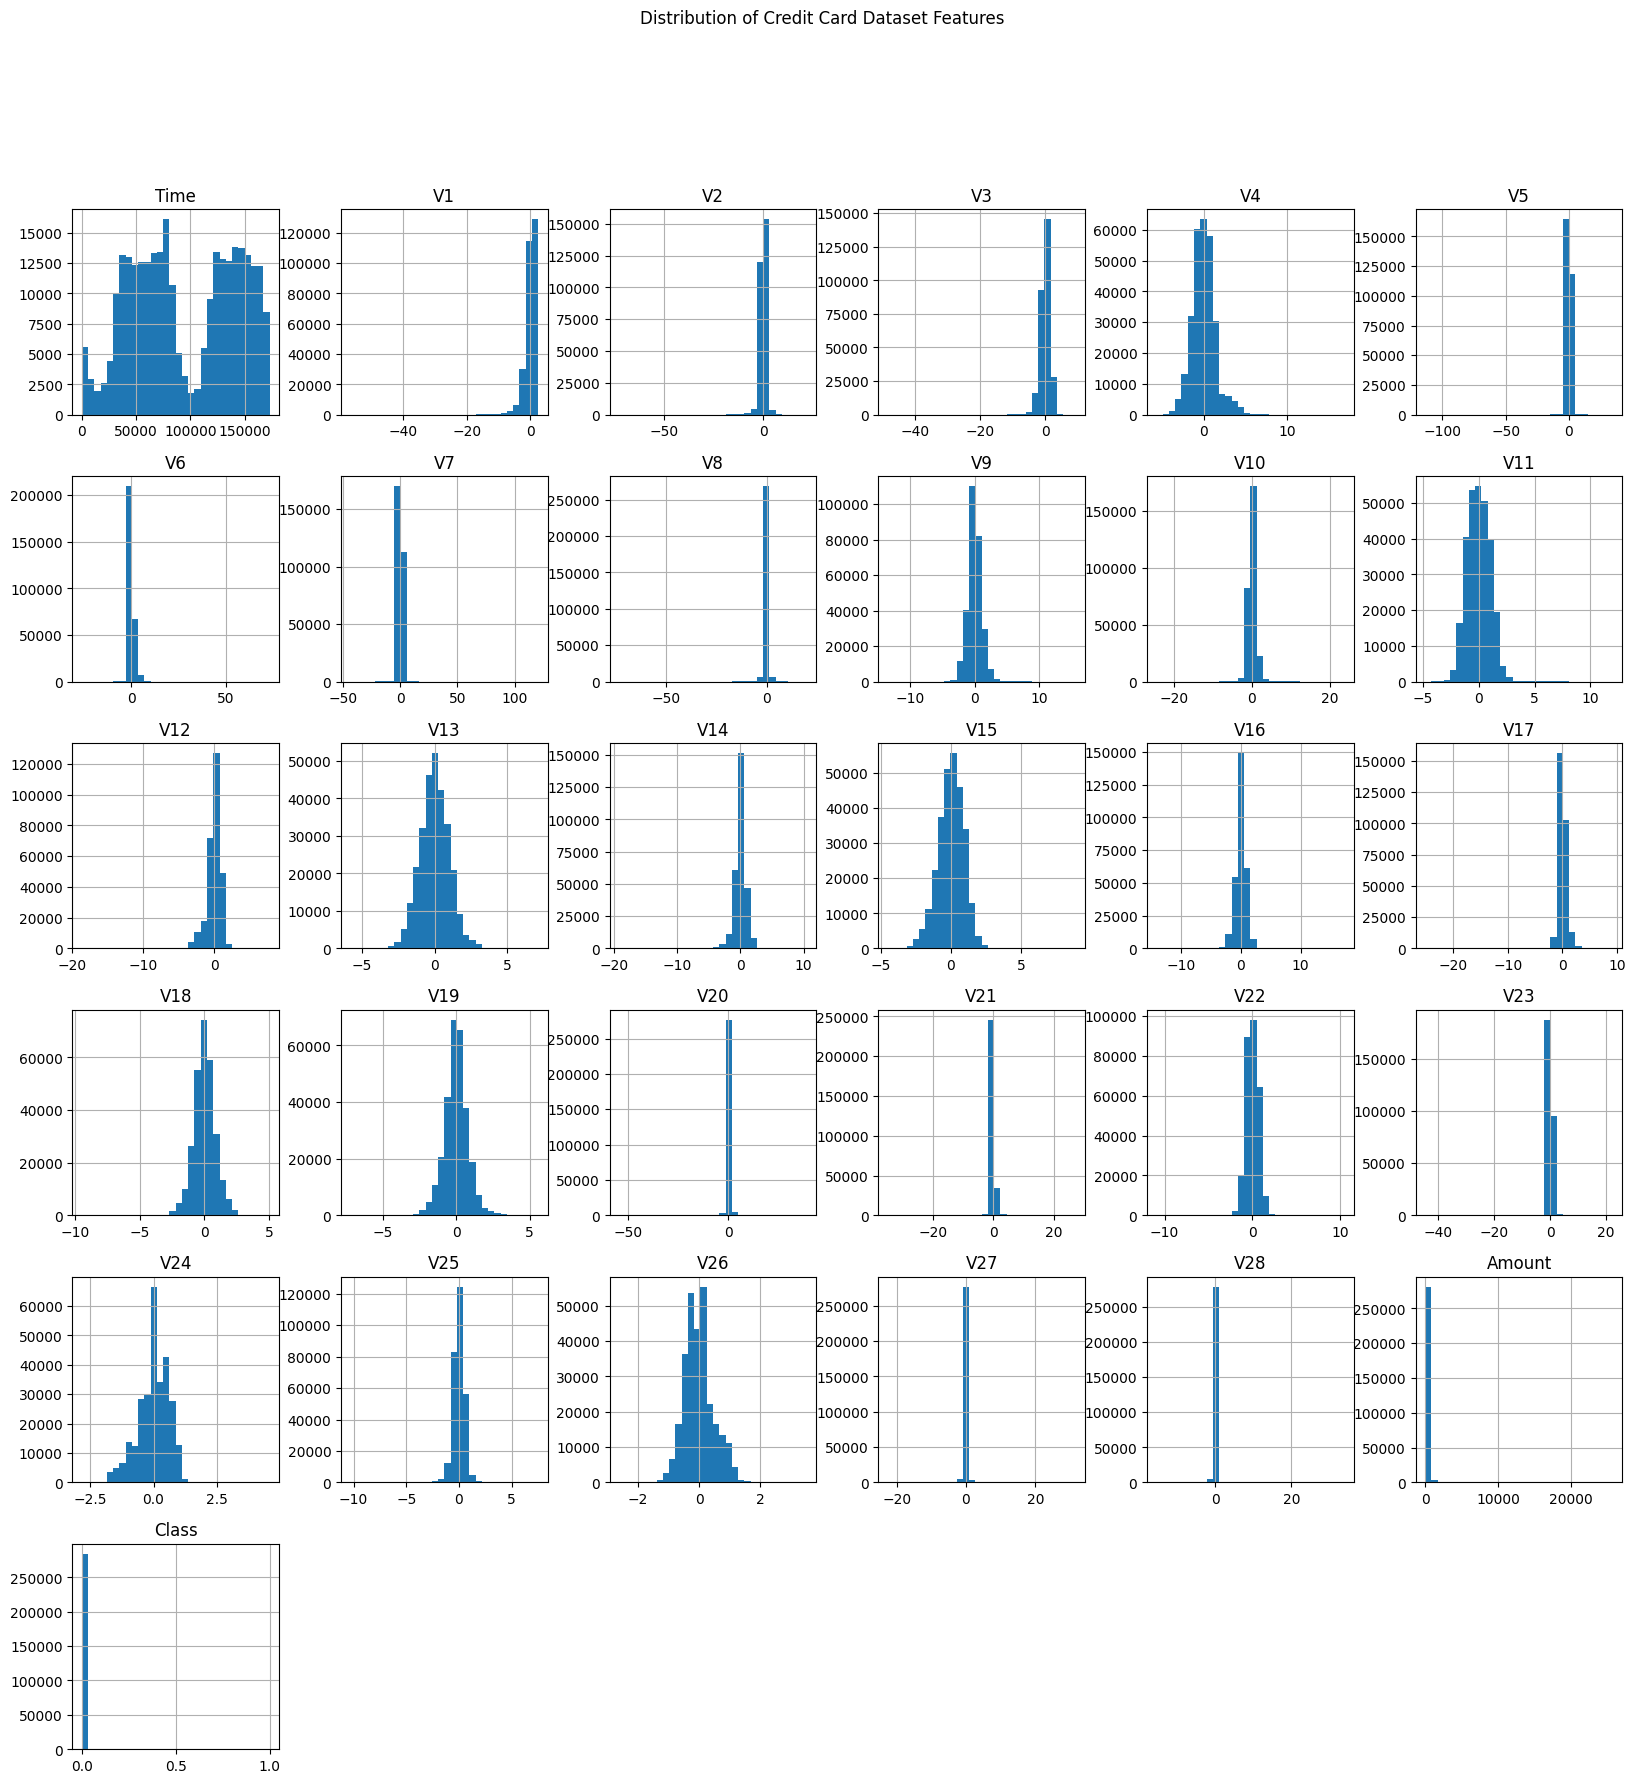

In [21]:
#Distribution of credit card features
###R///Fraud transaction typically show high magnitude deviations from normal clusters.
df.hist(figsize=(20, 20), bins=30)
plt.suptitle("Distribution of Credit Card Dataset Features")
plt.show()

###>>>Correlation

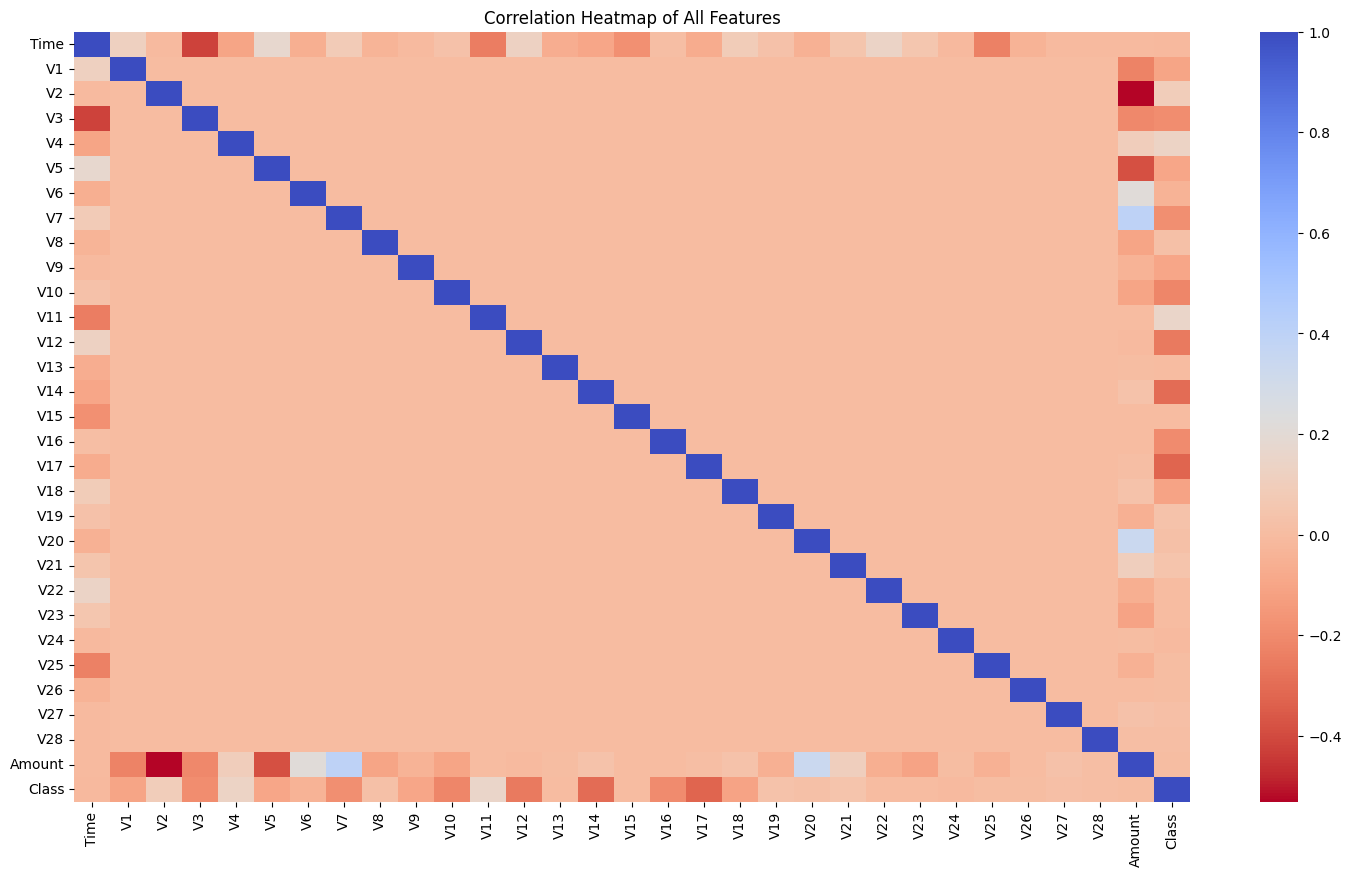

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [22]:
#Correlation headmap (Fraud vs Features)

plt.figure(figsize=(18, 10))
corr = df.corr()

sns.heatmap(corr, cmap="coolwarm_r", annot=False)
plt.title("Correlation Heatmap of All Features")
plt.show()

# Focus only on correlations with 'Class'
fraud_corr = corr["Class"].sort_values(ascending=False)
print(fraud_corr)

##R///

###>>>Detecting Outliers and patterns

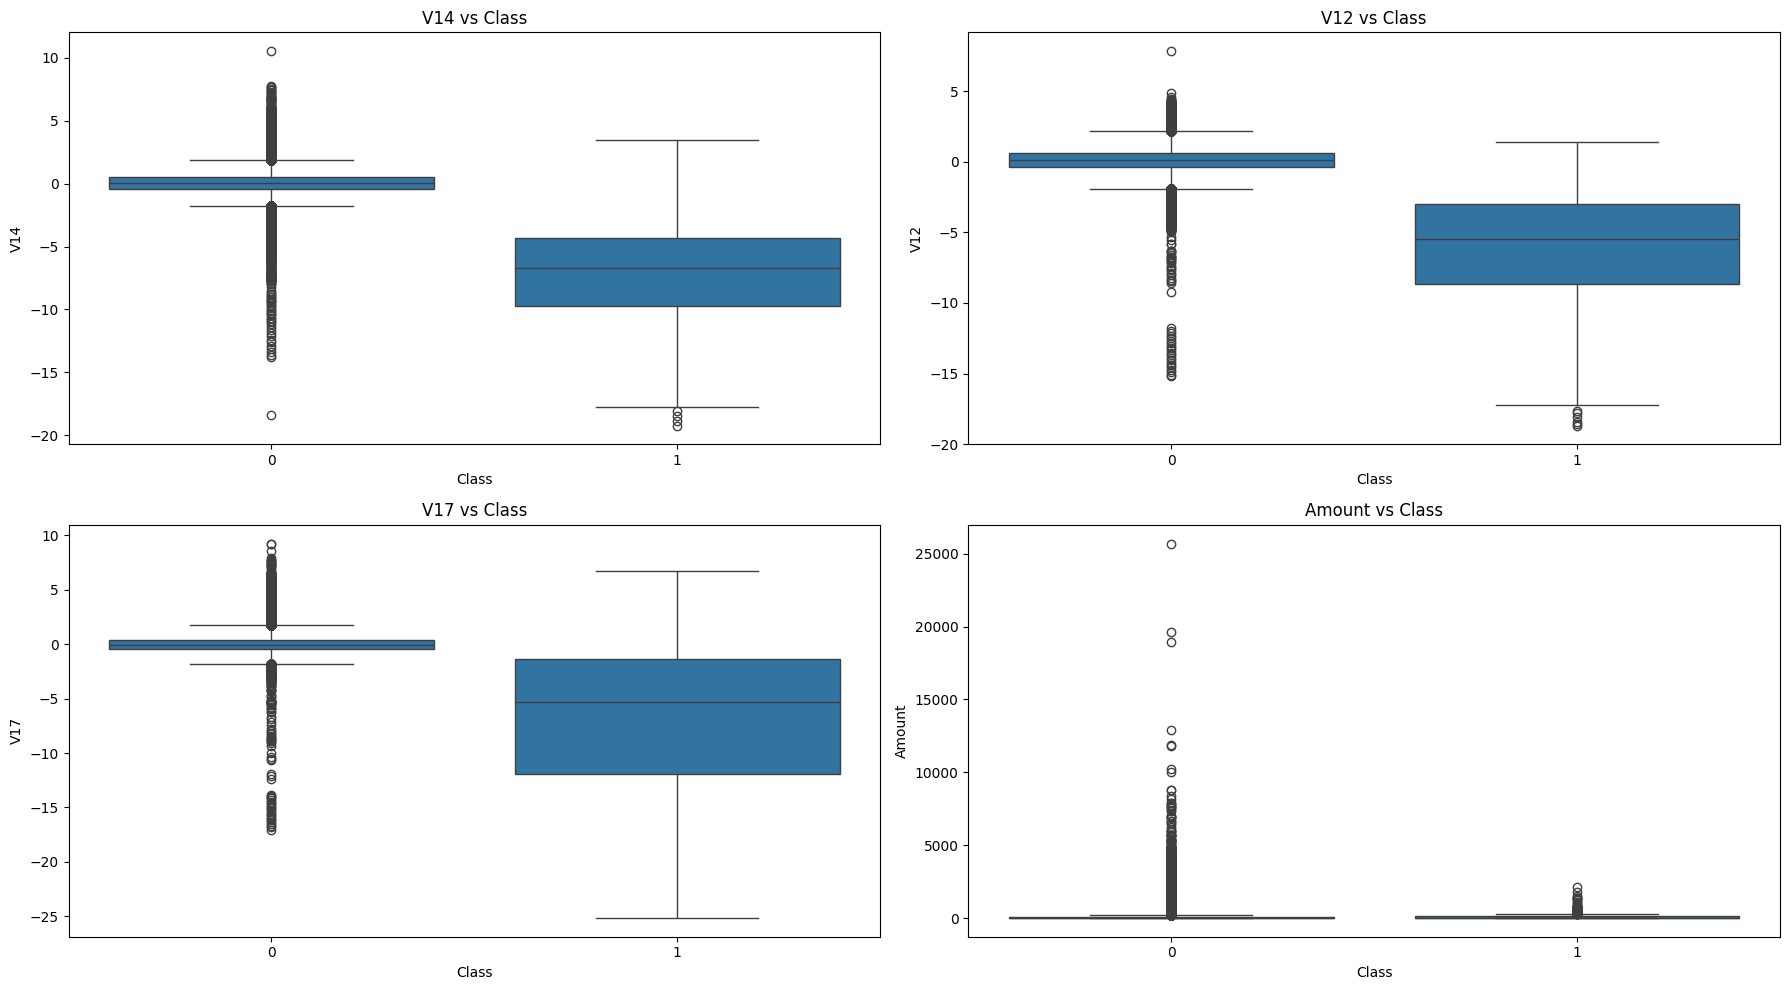

In [23]:
#Patterns
###R//Fraud cases cluster sharply in PCA components V14, V12, V17.
important_features = ["V14", "V12", "V17", "Amount"]

plt.figure(figsize=(18,10))

for i, feature in enumerate(important_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="Class", y=feature, data=df)
    plt.title(f"{feature} vs Class")

plt.tight_layout()
plt.show()

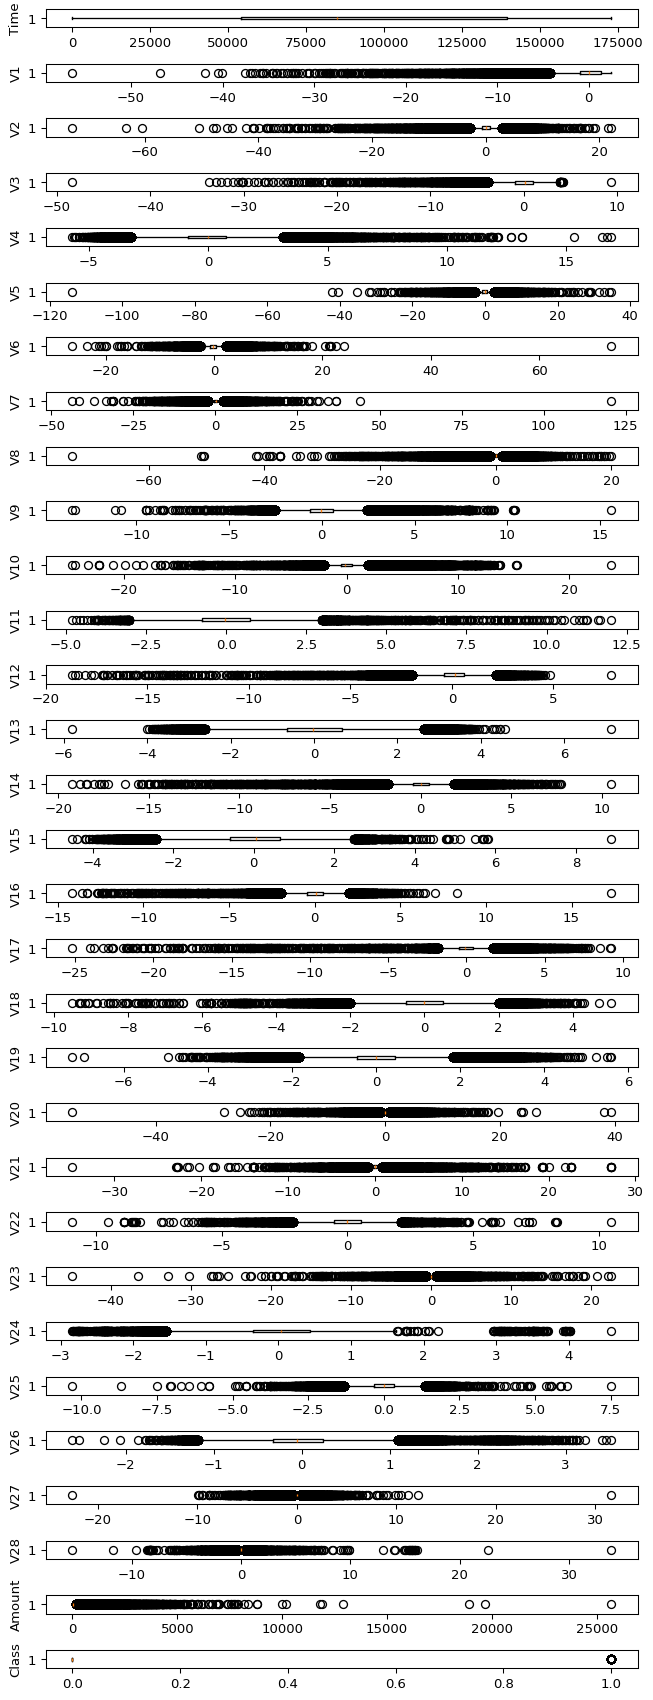

Outliers for column 'Time':


,Time


Outliers for column 'V1':


,V1
18,-5.401258
85,-4.575093
140,-5.101877
146,-5.285971
164,-6.093248
...,...
284631,-5.459612
284649,-11.946976
284772,-6.713826
284795,-12.516732


Outliers for column 'V2':


...

,V28
7,-1.085339
18,0.949594
64,0.316910
66,-0.473218
67,-0.272463
...,...
284760,0.281084
284769,-0.255729
284772,0.474584
284795,1.232864


Outliers for column 'Amount':


,Amount
2,378.66
20,231.71
51,1402.95
64,243.66
85,200.01
...,...
284735,381.05
284748,220.28
284753,337.54
284757,200.00


Outliers for column 'Class':


,Class
541,1
623,1
4920,1
6108,1
6329,1
...,...
279863,1
280143,1
280149,1
281144,1


In [19]:
# Visualise outliers
df.describe()

fig,axs=plt.subplots(len(df.columns),1,figsize=(7,18),dpi=95)
for i, col in enumerate(df.columns):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

# Calculate and print outliers for each column
for col in df.columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"Outliers for column '{col}':")
  display(outliers[[col]])

In [24]:
#Comparing mean values between fraud vs normal
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

fraud_mean = fraud.mean()
normal_mean = normal.mean()

comparison = pd.DataFrame({"Fraud Mean": fraud_mean, "Normal Mean": normal_mean})
print(comparison.head(20))

        Fraud Mean   Normal Mean
Time  80746.806911  94838.202258
V1       -4.771948      0.008258
V2        3.623778     -0.006271
V3       -7.033281      0.012171
V4        4.542029     -0.007860
V5       -3.151225      0.005453
V6       -1.397737      0.002419
V7       -5.568731      0.009637
V8        0.570636     -0.000987
V9       -2.581123      0.004467
V10      -5.676883      0.009824
V11       3.800173     -0.006576
V12      -6.259393      0.010832
V13      -0.109334      0.000189
V14      -6.971723      0.012064
V15      -0.092929      0.000161
V16      -4.139946      0.007164
V17      -6.665836      0.011535
V18      -2.246308      0.003887
V19       0.680659     -0.001178


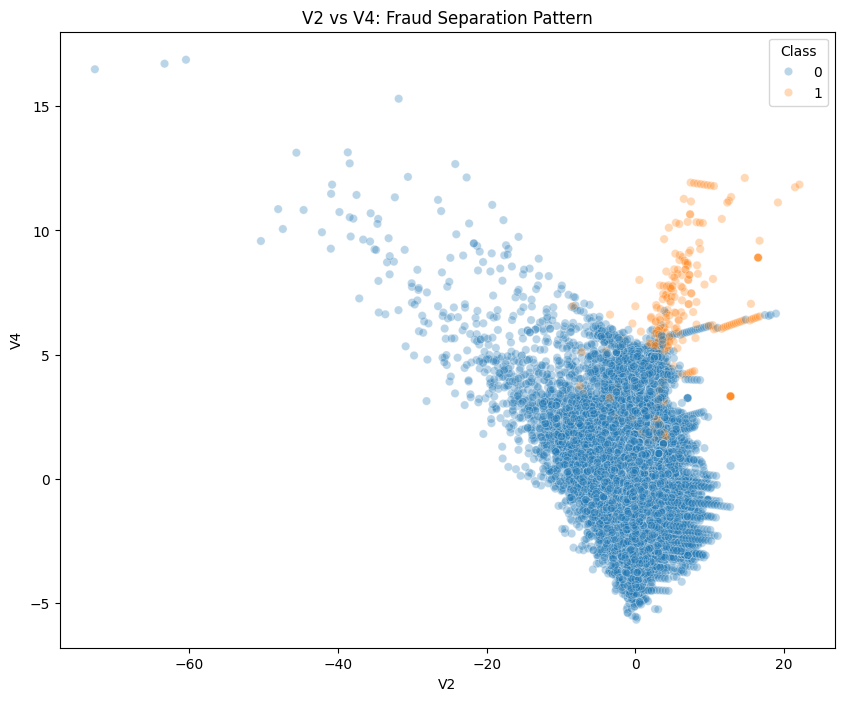

In [25]:
#Fraud separation pattern

plt.figure(figsize=(10,8))
sns.scatterplot(x="V2", y="V4", hue="Class", data=df, alpha=0.3)
plt.title("V2 vs V4: Fraud Separation Pattern")
plt.show()

######R//This scatter plot shows how fraud and non-fraud transactions separate when projected onto two PCA-derived features, V2 and V4. The blue points (legitimate transactions) form a large, diffuse cluster, while the orange fraud points appear in a narrower, distinct region with generally higher V2 and moderate-to-high V4 values. This indicates that fraud transactions follow a more specific pattern in PCA space, behaving differently from the broad variability of normal transactions. Even though these PCA features are anonymized, the graph reveals that fraud exhibits consistent, high-variance characteristics that PCA successfully isolates, making these components useful for distinguishing fraudulent behavior

In [26]:
# Look at fraud transactions sorted by anomaly-like features
fraud_sorted = fraud[["V14", "V12", "V17", "Amount"]].sort_values("V14")
print(fraud_sorted.head(10))

              V14        V12        V17  Amount
8296   -19.214325 -17.769143 -15.503392    1.00
8615   -18.822087 -17.631606 -15.227008    1.00
9035   -18.493773 -17.228662 -14.441211    1.00
9252   -18.049998 -17.131301 -14.744902    1.00
9487   -17.721638 -16.728339 -13.959085    1.00
41943  -17.620634 -14.168121 -21.675484    0.76
9509   -17.475921 -16.558197 -13.799148    1.00
10568  -17.230202 -16.388054 -13.639209    1.00
42590  -16.337596 -14.154165 -21.090613    5.30
150647 -15.623187 -18.553697 -20.159047    8.54
